## CIFAR-10

### Yêu cầu
- Phân tích dữ liệu 
- Cân bằng dữ liệu
- Xây dựng mô hình CNN thuần bằng PyTorch
- Huấn luyện và đánh giá mô hình
- Hạn chế overfitting

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader, random_split
from collections import Counter


## 1. Tải dữ liệu CIFAR-10

In [14]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

# Transform cơ bản để phân tích dữ liệu
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

# Tải tập train và test
full_train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=basic_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=basic_transform
)

print("Số ảnh train:", len(full_train_dataset))
print("Số ảnh test :", len(test_dataset))
print("Số lớp      :", len(classes))


Số ảnh train: 50000
Số ảnh test : 10000
Số lớp      : 10


## 2. Phân tích dữ liệu

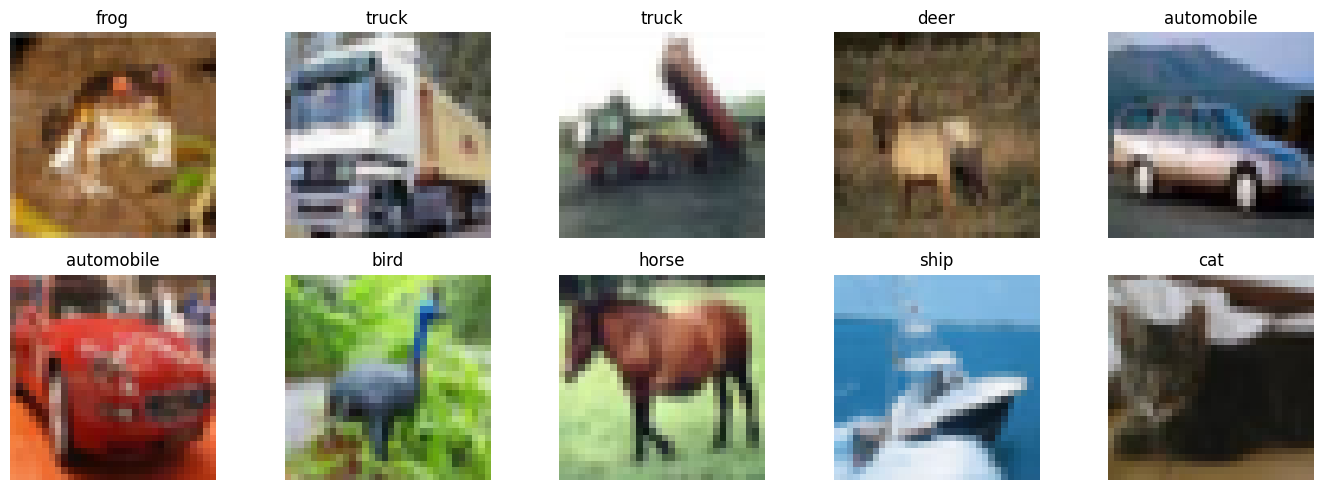

Kích thước ảnh mẫu: torch.Size([3, 32, 32])
Nhãn ảnh mẫu      : frog


In [15]:
# Hiển thị 10 ảnh mẫu
plt.figure(figsize=(14, 5))

for i in range(10):
    image, label = full_train_dataset[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(np.transpose(image.numpy(), (1, 2, 0)))
    plt.title(classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Kiểm tra kích thước một ảnh mẫu
sample_image, sample_label = full_train_dataset[0]
print("Kích thước ảnh mẫu:", sample_image.shape)
print("Nhãn ảnh mẫu      :", classes[sample_label])


Phân bố số lượng ảnh theo lớp:
airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


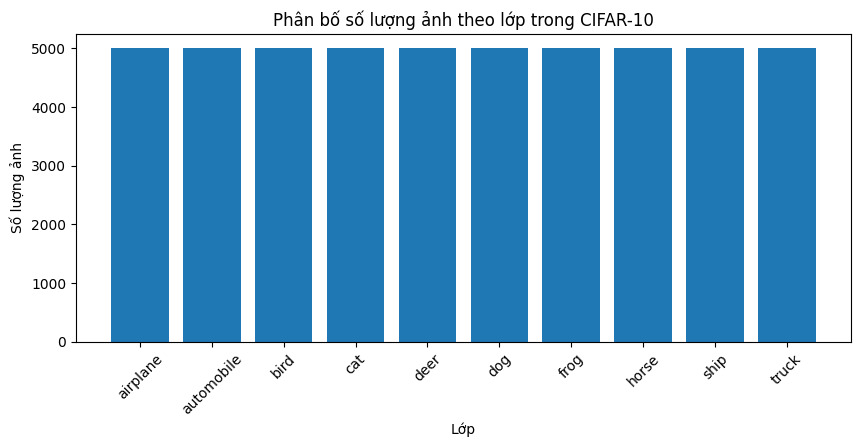

In [16]:
# Đếm số lượng ảnh theo từng lớp
train_labels = [label for _, label in full_train_dataset]
label_counts = Counter(train_labels)

print("Phân bố số lượng ảnh theo lớp:")
for idx, count in sorted(label_counts.items()):
    print(f"{classes[idx]}: {count}")

# Vẽ biểu đồ phân bố lớp
plt.figure(figsize=(10, 4))
plt.bar(classes, [label_counts[i] for i in range(len(classes))])
plt.title("Phân bố số lượng ảnh theo lớp trong CIFAR-10")
plt.xlabel("Lớp")
plt.ylabel("Số lượng ảnh")
plt.xticks(rotation=45)
plt.show()


## 3. Tiền xử lý dữ liệu và giảm overfitting

In [17]:
# Transform cho tập train: có augmentation để giảm overfitting
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

# Transform cho validation/test: không augmentation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

# Tải lại tập train với 2 transform khác nhau
train_dataset_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)

val_dataset_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=test_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

# Chia chỉ số train/validation
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

indices = torch.randperm(len(train_dataset_full)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Tạo tập train/validation riêng
train_dataset = torch.utils.data.Subset(train_dataset_full, train_indices)
val_dataset = torch.utils.data.Subset(val_dataset_full, val_indices)

print("Số ảnh train      :", len(train_dataset))
print("Số ảnh validation :", len(val_dataset))
print("Số ảnh test       :", len(test_dataset))

Số ảnh train      : 40000
Số ảnh validation : 10000
Số ảnh test       : 10000


In [18]:
# Tạo DataLoader
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Số batch train:", len(train_loader))
print("Số batch val  :", len(val_loader))
print("Số batch test :", len(test_loader))


Số batch train: 313
Số batch val  : 79
Số batch test : 79


## 4. Xây dựng mô hình CNN cơ bản

In [19]:
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 5. Khởi tạo mô hình

In [21]:
# Khởi tạo mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CIFAR10_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',      # vì mình theo dõi val_acc
    factor=0.5,
    patience=3
)

print(model)
print("Thiết bị đang dùng:", device)

CIFAR10_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(

In [22]:
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
print("Images shape:", images.shape)
print("Outputs shape:", outputs.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([128, 3, 32, 32])
Outputs shape: torch.Size([128, 10])
Labels shape: torch.Size([128])


## 6. Huấn luyện mô hình

In [23]:
# Hàm tính độ chính xác
def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    return 100 * correct / labels.size(0)

In [26]:
# Huấn luyện mô hình
num_epochs = 30
patience = 6

train_loss_values = []
train_accuracy_values = []
val_loss_values = []
val_accuracy_values = []

for epoch in range(num_epochs):
    model.train()  # Chuyển mô hình sang chế độ train

    running_loss = 0.0
    running_accuracy = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # Xóa gradient cũ
        outputs = model(images)  # Lan truyền xuôi
        loss = criterion(outputs, labels)  # Tính loss
        loss.backward()  # Lan truyền ngược
        optimizer.step()  # Cập nhật trọng số

        running_loss += loss.item()
        running_accuracy += calculate_accuracy(outputs, labels)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_accuracy = running_accuracy / len(train_loader)

    train_loss_values.append(epoch_train_loss)
    train_accuracy_values.append(epoch_train_accuracy)

    # Đánh giá trên tập validation
    model.eval()
    val_running_loss = 0.0
    val_running_accuracy = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            val_running_accuracy += calculate_accuracy(outputs, labels)

    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_accuracy = val_running_accuracy / len(val_loader)

    val_loss_values.append(epoch_val_loss)
    val_accuracy_values.append(epoch_val_accuracy)

    scheduler.step(epoch_val_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {epoch_train_loss:.4f}, "
          f"Train Acc: {epoch_train_accuracy:.2f}%, "
          f"Val Loss: {epoch_val_loss:.4f}, "
          f"Val Acc: {epoch_val_accuracy:.2f}%")

Epoch [1/30], Train Loss: 0.4832, Train Acc: 83.88%, Val Loss: 0.5047, Val Acc: 84.04%
Epoch [2/30], Train Loss: 0.4622, Train Acc: 84.89%, Val Loss: 0.4989, Val Acc: 83.45%
Epoch [3/30], Train Loss: 0.4626, Train Acc: 84.49%, Val Loss: 0.5173, Val Acc: 83.58%
Epoch [4/30], Train Loss: 0.4365, Train Acc: 85.37%, Val Loss: 0.4638, Val Acc: 84.69%
Epoch [5/30], Train Loss: 0.4192, Train Acc: 86.14%, Val Loss: 0.4545, Val Acc: 84.93%
Epoch [6/30], Train Loss: 0.4118, Train Acc: 86.48%, Val Loss: 0.4841, Val Acc: 84.13%
Epoch [7/30], Train Loss: 0.4003, Train Acc: 86.80%, Val Loss: 0.4258, Val Acc: 85.96%
Epoch [8/30], Train Loss: 0.3906, Train Acc: 86.87%, Val Loss: 0.5251, Val Acc: 83.97%
Epoch [9/30], Train Loss: 0.3802, Train Acc: 87.38%, Val Loss: 0.4227, Val Acc: 86.47%
Epoch [10/30], Train Loss: 0.3762, Train Acc: 87.66%, Val Loss: 0.4771, Val Acc: 84.67%
Epoch [11/30], Train Loss: 0.3660, Train Acc: 87.82%, Val Loss: 0.4317, Val Acc: 86.00%
Epoch [12/30], Train Loss: 0.3511, Train 

## 7. Vẽ biểu đồ Loss và Accuracy

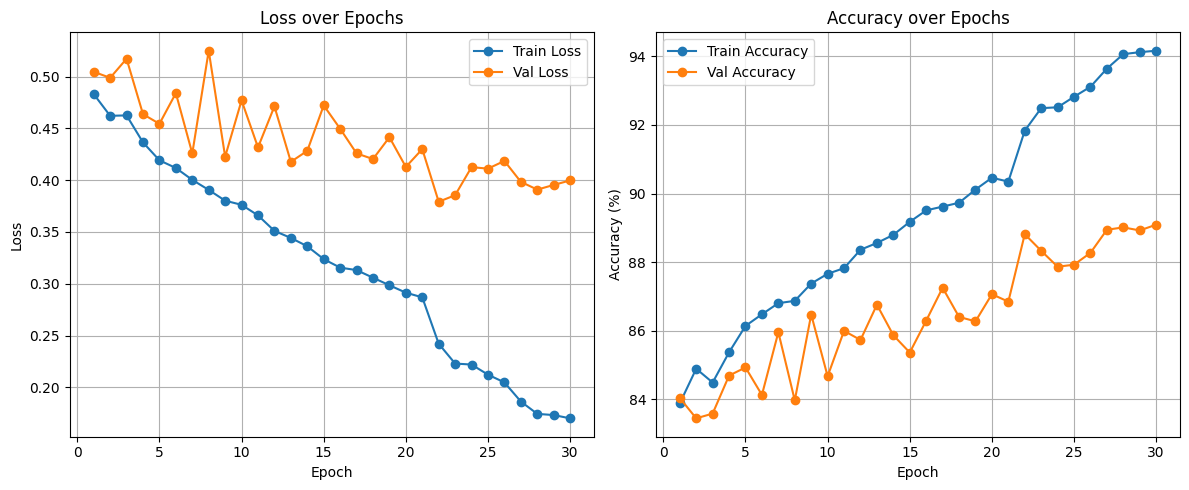

In [27]:
plt.figure(figsize=(12, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss_values) + 1), train_loss_values, marker='o', label='Train Loss')
plt.plot(range(1, len(val_loss_values) + 1), val_loss_values, marker='o', label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Biểu đồ Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracy_values) + 1), train_accuracy_values, marker='o', label='Train Accuracy')
plt.plot(range(1, len(val_accuracy_values) + 1), val_accuracy_values, marker='o', label='Val Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## 8. Đánh giá mô hình trên tập test

In [28]:
correct = 0  # Đếm số dự đoán đúng
total = 0  # Đếm tổng số mẫu

model.eval()  # Chuyển sang chế độ đánh giá

with torch.no_grad():  # Tắt tính gradient
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Độ chính xác trên tập test: {100 * correct / total:.2f}%")


Độ chính xác trên tập test: 88.70%


## 9. Trực quan kết quả dự đoán

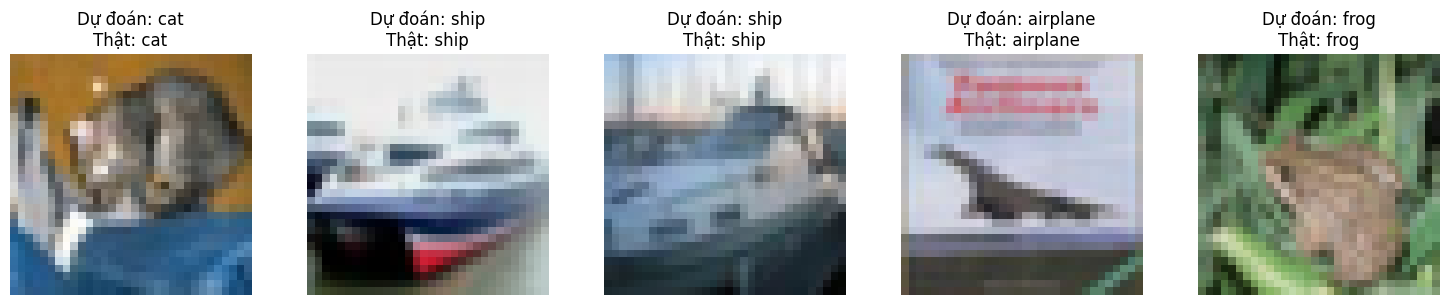

In [29]:
# Hàm hiển thị ảnh
def imshow(img):
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)

# Lấy một batch ảnh từ tập test
dataiter = iter(test_loader)
images, labels = next(dataiter)

images_show = images[:5]
labels_show = labels[:5]

model.eval()
with torch.no_grad():
    outputs = model(images_show.to(device))
    _, predicted = torch.max(outputs, 1)

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    imshow(images_show[i].cpu())
    plt.title(f"Dự đoán: {classes[predicted[i].item()]}\nThật: {classes[labels_show[i].item()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 10. Trực quan feature map

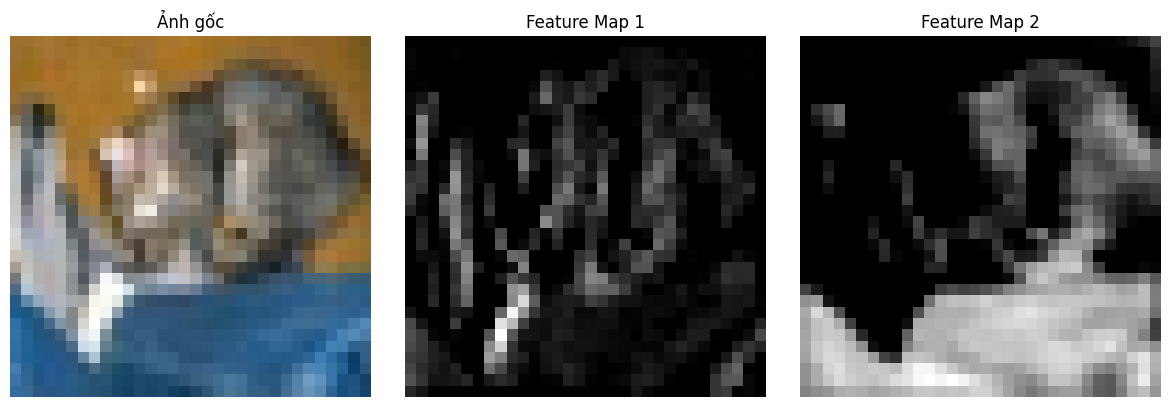

In [32]:
# Trực quan feature map từ tầng conv đầu tiên
def visualize_feature_map():
    model.eval()
    images, _ = next(iter(test_loader))
    img = images[0].unsqueeze(0).to(device)

    with torch.no_grad():
        conv1_output = model.features[0](img)   # lớp Conv2d đầu tiên
        conv1_output = torch.relu(conv1_output)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.title("Ảnh gốc")
    imshow(images[0].cpu())
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Feature Map 1")
    plt.imshow(conv1_output[0, 0].cpu().numpy(), cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Feature Map 2")
    plt.imshow(conv1_output[0, 1].cpu().numpy(), cmap='gray')
    plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_feature_map()

## Nhận xét:

Bộ dữ liệu PlantVillage có số lượng lớp lớn (nhiều loại bệnh lá cây khác nhau) và độ phức tạp cao hơn so với hai dataset còn lại. Hình ảnh có kích thước lớn hơn và đa dạng hơn về màu sắc, kết cấu và đặc trưng bệnh.

Kết quả huấn luyện cho thấy:

train accuracy tăng đều (từ ~52% lên ~85%)

validation accuracy duy trì thấp (~49%)

Điều này cho thấy mô hình học tốt trên tập huấn luyện nhưng không tổng quát hóa tốt trên tập validation, biểu hiện rõ của hiện tượng overfitting.

Nguyên nhân có thể bao gồm:
- số lượng lớp lớn → bài toán khó hơn
- dữ liệu giữa train và validation chưa cân bằng tốt
- thời gian huấn luyện còn hạn chế (10 epoch)

mô hình CNN thuần chưa đủ mạnh để học đặc trưng phức tạp